In [1]:
!pip install psycopg2-binary sqlalchemy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 41.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
from sqlalchemy import create_engine

from google.colab import userdata
DATABASE_URL = userdata.get('DATABASE_URL')

engine = create_engine(DATABASE_URL)
print("Connexion établie.")

Connexion établie.


In [4]:
query = """
    SELECT c.city_name, c.country, t.date, t.hour, t.day_of_week, t.day_name, t.is_weekend,
           f.aqi_owm, f.pm2_5, f.pm10, f.co, f.no2, f.o3, f.so2
    FROM fact_air_quality f
    JOIN dim_city c ON c.city_key = f.city_key
    JOIN dim_time t ON t.time_key = f.time_key
    ORDER BY t.date, t.hour
"""
df = pd.read_sql(query, engine)
print(f"{len(df)} lignes chargées.")
df.head()

70 lignes chargées.


,city_name,country,date,hour,day_of_week,day_name,is_weekend,aqi_owm,pm2_5,pm10,co,no2,o3,so2
0,Antananarivo,MG,2026-07-18,7,5,samedi,True,1,8.48,10.80,163.12,0.39,56.44,0.45
1,Los Angeles,US,2026-07-18,7,5,samedi,True,2,8.17,22.93,93.13,0.53,80.84,0.99
2,Paris,FR,2026-07-18,7,5,samedi,True,1,5.74,8.61,115.97,4.06,58.31,0.85
3,Beijing,CN,2026-07-18,7,5,samedi,True,4,69.02,71.68,191.90,2.78,157.55,9.06
4,New Delhi,IN,2026-07-18,7,5,samedi,True,2,12.39,41.43,119.41,2.68,62.60,1.17


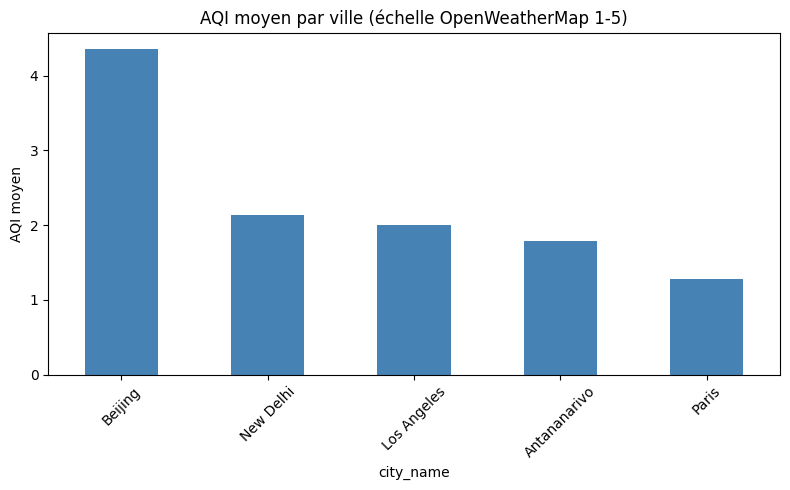

In [5]:
import matplotlib.pyplot as plt

aqi_par_ville = df.groupby("city_name")["aqi_owm"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
aqi_par_ville.plot(kind="bar", color="steelblue")
plt.title("AQI moyen par ville (échelle OpenWeatherMap 1-5)")
plt.ylabel("AQI moyen")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

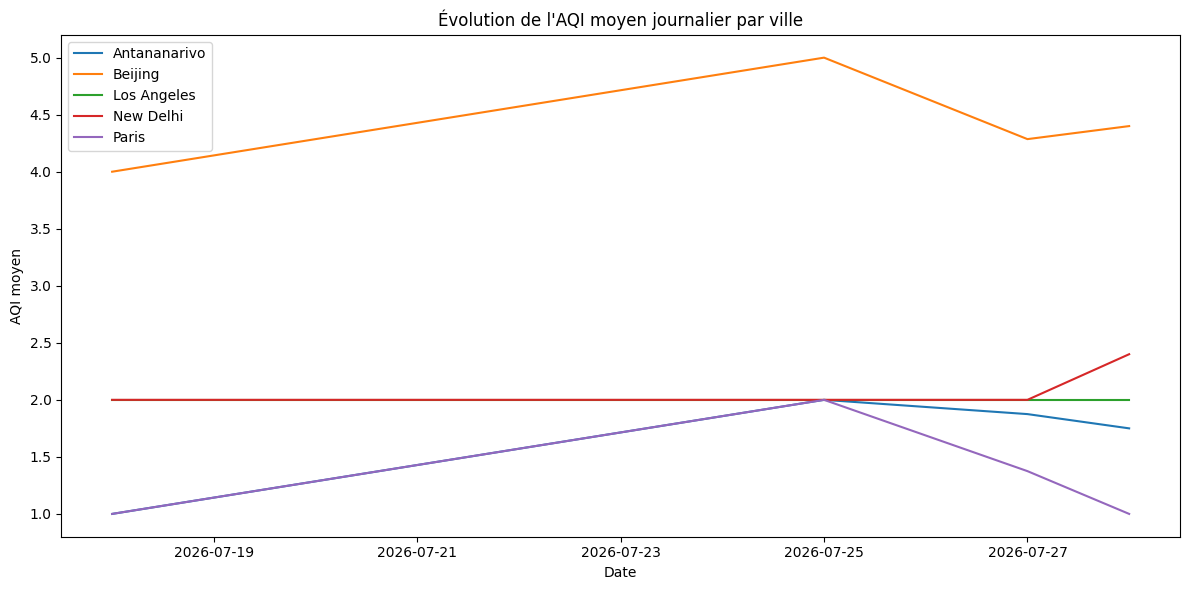

In [6]:
df["date"] = pd.to_datetime(df["date"])
evolution = df.groupby(["date", "city_name"])["aqi_owm"].mean().unstack()

plt.figure(figsize=(12, 6))
for ville in evolution.columns:
    plt.plot(evolution.index, evolution[ville], label=ville)
plt.title("Évolution de l'AQI moyen journalier par ville")
plt.xlabel("Date")
plt.ylabel("AQI moyen")
plt.legend()
plt.tight_layout()
plt.show()

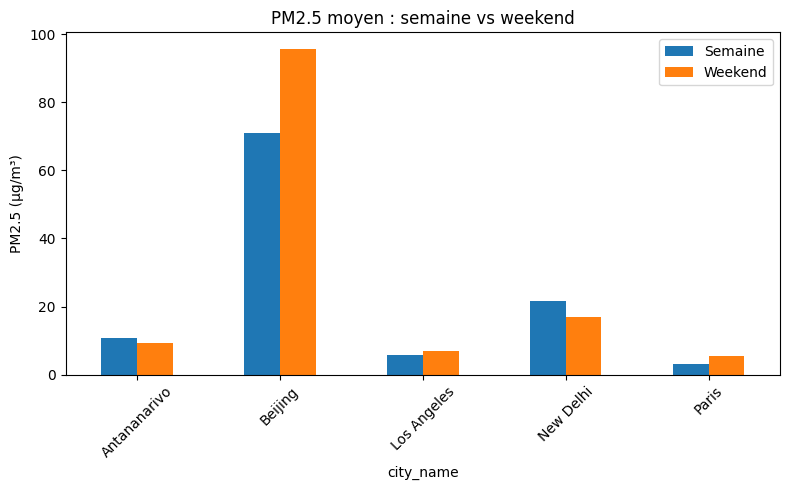

In [7]:
weekend_comparison = df.groupby(["city_name", "is_weekend"])["pm2_5"].mean().unstack()
weekend_comparison.columns = ["Semaine", "Weekend"]

weekend_comparison.plot(kind="bar", figsize=(8, 5))
plt.title("PM2.5 moyen : semaine vs weekend")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

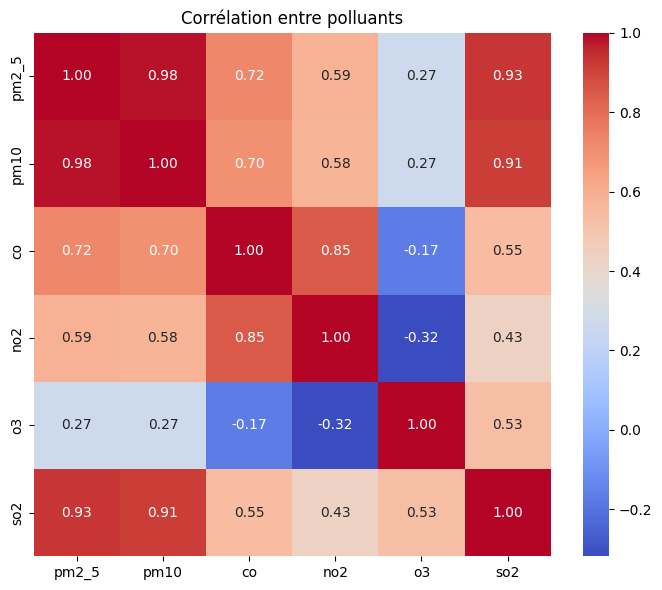

In [8]:
import seaborn as sns

polluants = ["pm2_5", "pm10", "co", "no2", "o3", "so2"]
corr = df[polluants].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélation entre polluants")
plt.tight_layout()
plt.show()